In [1]:
import matplotlib
from matplotlib import pyplot as plt
import numpy as np

%matplotlib inline

In [2]:
wc_genes = {'type1': 42670152,
            'type2': 42428575,
            'type3': 42076549,
            'type4': 42581932}

wc_tes = {'type1': {'LINE': 1034582,
                    'SINE': 74074,
                    'other TE': 173376,
                    'ERV': 39699},
          'type2': {'LINE': 1090096,
                    'SINE': 80512,
                    'other TE': 259625,
                    'ERV': 44768},
          'type3': {'LINE': 1484290,
                    'SINE': 85068,
                    'other TE': 110771,
                    'ERV': 43405},
          'type4': {'LINE': 1026182,
                    'SINE': 73985,
                    'other TE': 159476,
                    'ERV': 49015}}

ns_genes = {'type1': 42751263,
            'type2': 42570479,
            'type3': 42257927,
            'type4': 42711520}

ns_tes = {'type1': {'LINE': 987421,
                    'SINE': 68837,
                    'other TE': 148823,
                    'ERV': 35680},
          'type2': {'LINE': 1004579,
                    'SINE': 72842,
                    'other TE': 217395,
                    'ERV': 38581},
          'type3': {'LINE': 1312492,
                    'SINE': 78650,
                    'other TE': 113300,
                    'ERV': 38106},
          'type4': {'LINE': 932493,
                    'SINE': 67760,
                    'other TE': 138015,
                    'ERV': 41054}}

wc_sums = {'type1':0, 'type2':0, 'type3':0, 'type4':0}
for typ in wc_genes:
    wc_sums[typ] += wc_genes[typ]
    for subf in wc_tes[typ]:
        wc_sums[typ] += wc_tes[typ][subf]

ns_sums = {'type1':0, 'type2':0, 'type3':0, 'type4':0}
for typ in ns_genes:
    ns_sums[typ] += ns_genes[typ]
    for subf in ns_tes[typ]:
        ns_sums[typ] += ns_tes[typ][subf]

In [3]:
wc_sums = {'type1':0, 'type2':0, 'type3':0, 'type4':0}
for typ in wc_genes:
    for subf in wc_tes[typ]:
        wc_sums[typ] += wc_tes[typ][subf]

ns_sums = {'type1':0, 'type2':0, 'type3':0, 'type4':0}
for typ in ns_genes:
    for subf in ns_tes[typ]:
        ns_sums[typ] += ns_tes[typ][subf]

In [4]:
stackorder = ['Other TEs', 'ERVs', 'SINEs', 'LINEs']

baseline = np.zeros(4)
frac_tots = {'Whole Cell':{'type1':[], 'type2':[], 'type3':[], 'type4':[]}, 'Single Nucleus':{'type1':[], 'type2':[], 'type3':[], 'type4':[]}}

for typ in frac_tots['Whole Cell']:
    frac_tots['Whole Cell'][typ].append(0)
    frac_tots['Single Nucleus'][typ].append(0)
    for subf in ['other TE', 'ERV', 'SINE']:  #, 'LINE']:
        wctemp = wc_tes[typ][subf]/wc_sums[typ]
        nstemp = ns_tes[typ][subf]/ns_sums[typ]
        frac_tots['Whole Cell'][typ].append(frac_tots['Whole Cell'][typ][-1]+wctemp)
        frac_tots['Single Nucleus'][typ].append(frac_tots['Single Nucleus'][typ][-1]+nstemp)
    frac_tots['Whole Cell'][typ].append(1)
    frac_tots['Single Nucleus'][typ].append(1)

In [5]:
frac_tots

{'Whole Cell': {'type1': [0,
   0.13117343846819057,
   0.16120905085830625,
   0.21725222454493387,
   1],
  'type2': [0, 0.17601682981909844, 0.2063679956827148, 0.2609523654560234, 1],
  'type3': [0,
   0.06426969238784962,
   0.08945341374176546,
   0.1388101424166857,
   1],
  'type4': [0,
   0.12186224361139426,
   0.15931664346223384,
   0.21585165872214132,
   1]},
 'Single Nucleus': {'type1': [0,
   0.11994493701849107,
   0.14870148239669043,
   0.20418114366908696,
   1],
  'type2': [0,
   0.1630384649133004,
   0.19197283329721007,
   0.24660172476764236,
   1],
  'type3': [0, 0.0734499023693266, 0.09815318550865192, 0.149140253658233, 1],
  'type4': [0, 0.117029106554444, 0.15184063385572388, 0.2092973759499102, 1]}}

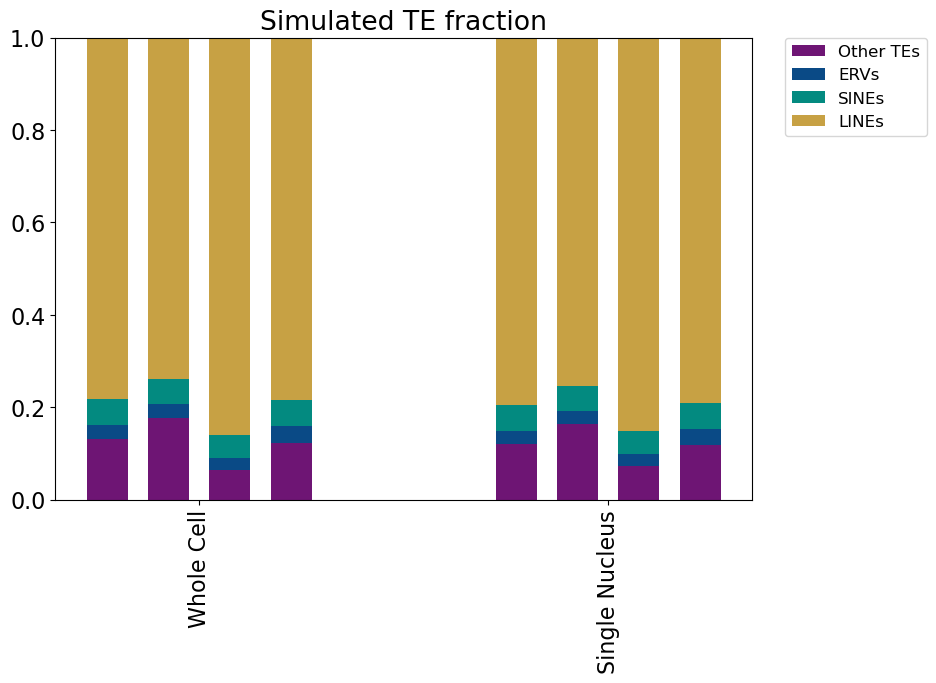

In [7]:
plt.figure(figsize=(9,6))
exs = []
elabs = []
cond_counter = 1
colorset = ['#6e1574', '#0a4a86', '#038a80', '#c7a144']
labels_stacked = stackorder

stacker = {}
offset = {'type1':-0.225,'type2':-0.075, 'type3':0.075, 'type4':0.225}

labels = True

for etype in ['Whole Cell', 'Single Nucleus']:
    elabs.append(etype)
    exs.append(cond_counter)
    stacker[etype] = {}
    
    for typ in offset:
        stacker[etype][typ] = []
        for n in range(len(labels_stacked)):
            stacker[etype][typ].append([frac_tots[etype][typ][n], frac_tots[etype][typ][n+1]-frac_tots[etype][typ][n]])

        if labels:
            for n in range(len(labels_stacked)):
                plt.bar([cond_counter+offset[typ]], stacker[etype][typ][n][1], align='center', width=0.1, bottom=stacker[etype][typ][n][0], color=colorset[n], label=labels_stacked[n])
            labels = False
        else:
            for n in range(len(labels_stacked)):
                plt.bar([cond_counter+offset[typ]], stacker[etype][typ][n][1], align='center', width=0.1, bottom=stacker[etype][typ][n][0], color=colorset[n])

            
    cond_counter += 1

plt.xticks(exs, elabs, rotation='vertical')
plt.ylim([0,1])
plt.rcParams.update({'font.size': 16})

plt.legend(loc='upper right', prop={'size':12}, bbox_to_anchor=(1.25, 1), borderaxespad=0.)
plt.title('Simulated TE fraction')
plt.savefig('25.11.08_Fig2_D1.png', bbox_inches="tight", pad_inches=0.2)
plt.show()

In [7]:
stacker['Whole Cell']['type2'][n][1]

0.7390476345439766

In [8]:
# whole cell and nuc seq TE breakdowns were calculated on the server, check /gpfs/home/forcit01/storage/TEsingle/24_simulate_data/flux-sim/t2t

wc_tot = 5828924
wc_intronic = 593471
wc_l1pa23 = 4017251
wc_alu = 236419
wc_sva = 613908
wc_erv = 176745

ns_tot = 5296028
ns_intronic = 557912
ns_l1pa23 = 3677427
ns_alu = 217809
ns_sva = 532191
ns_erv = 153240

wc_intergenic = wc_tot - wc_intronic
wc_rand = wc_tot - (wc_l1pa23+wc_alu+wc_sva+wc_erv)

ns_intergenic = ns_tot - ns_intronic
ns_rand = ns_tot - (ns_l1pa23+ns_alu+ns_sva+ns_erv)

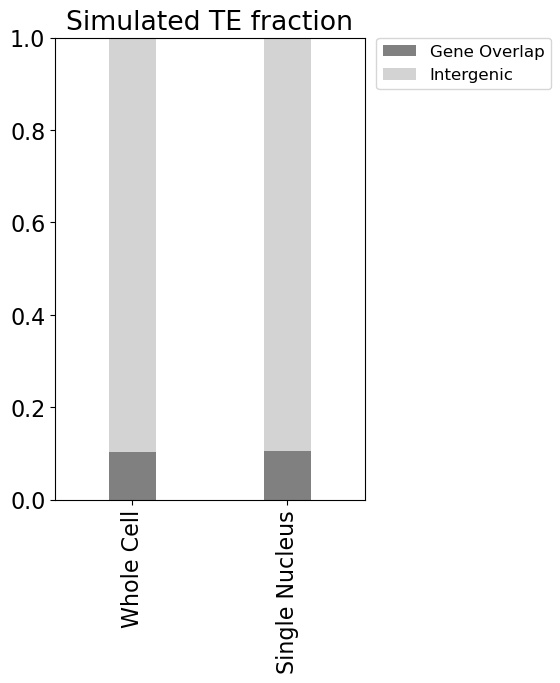

In [9]:
# for each chunk of the stacked bar we want [baseline, height], and ideally all heights add to 1
newstack = {'Whole Cell':[[0, wc_intronic/wc_tot],[wc_intronic/wc_tot, wc_intergenic/wc_tot]], 
            'Single Nucleus':[[0, ns_intronic/ns_tot],[ns_intronic/ns_tot, ns_intergenic/ns_tot]]}


plt.figure(figsize=(4,6))
exs = []
elabs = []
cond_counter = 1
colorset = ['gray', 'lightgray']
labels_stacked = ['Gene Overlap', 'Intergenic']

offset = {'Whole Cell':-0.2,'Single Nucleus':0.2}

labels = True

for etype in ['Whole Cell', 'Single Nucleus']:
    elabs.append(etype)
    exs.append(cond_counter)
    
    if labels:
        for n in range(len(labels_stacked)):
            plt.bar([cond_counter], newstack[etype][n][1], align='center', width=0.3, bottom=newstack[etype][n][0], color=colorset[n], label=labels_stacked[n])
        labels = False
    else:
        for n in range(len(labels_stacked)):
            plt.bar([cond_counter], newstack[etype][n][1], align='center', width=0.3, bottom=newstack[etype][n][0], color=colorset[n])

            
    cond_counter += 1

plt.xticks(exs, elabs, rotation='vertical')
plt.ylim([0,1])
plt.xlim([0.5,2.5])
plt.rcParams.update({'font.size': 16})

plt.legend(loc='upper right', prop={'size':12}, bbox_to_anchor=(1.6, 1), borderaxespad=0.)
plt.title('Simulated TE fraction')
plt.savefig('25.11.08_Fig2_D2.png', bbox_inches="tight", pad_inches=0.2)
plt.show()

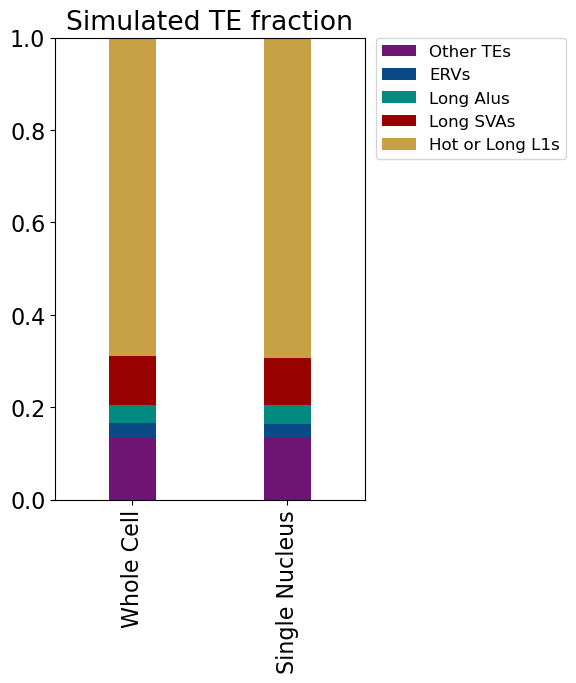

In [17]:
# for each chunk of the stacked bar we want [baseline, height], and ideally all heights add to 1
newstack = {'Whole Cell':[[0, wc_rand/wc_tot],
                          [wc_rand/wc_tot, wc_erv/wc_tot], 
                          [(wc_erv+wc_rand)/wc_tot, wc_alu/wc_tot],
                          [(wc_erv+wc_rand+wc_alu)/wc_tot, wc_sva/wc_tot],
                          [(wc_tot-wc_l1pa23)/wc_tot, wc_l1pa23/wc_tot]], 
            'Single Nucleus':[[0, ns_rand/ns_tot],
                             [ns_rand/ns_tot, ns_erv/ns_tot], 
                             [(ns_erv+ns_rand)/ns_tot, ns_alu/ns_tot],
                             [(ns_erv+ns_rand+ns_alu)/ns_tot, ns_sva/ns_tot],
                             [(ns_tot-ns_l1pa23)/ns_tot, ns_l1pa23/ns_tot]]
           }


plt.figure(figsize=(4,6))
exs = []
elabs = []
cond_counter = 1
colorset = ['#6e1574', '#0a4a86', '#038a80', '#990000', '#c7a144']
labels_stacked = ['Other TEs', 'ERVs', 'Long Alus', 'Long SVAs', 'Hot or Long L1s']

offset = {'Whole Cell':-0.2,'Single Nucleus':0.2}

labels = True

for etype in ['Whole Cell', 'Single Nucleus']:
    elabs.append(etype)
    exs.append(cond_counter)
    
    if labels:
        for n in range(len(labels_stacked)):
            plt.bar([cond_counter], newstack[etype][n][1], align='center', width=0.3, bottom=newstack[etype][n][0], color=colorset[n], label=labels_stacked[n])
        labels = False
    else:
        for n in range(len(labels_stacked)):
            plt.bar([cond_counter], newstack[etype][n][1], align='center', width=0.3, bottom=newstack[etype][n][0], color=colorset[n])

            
    cond_counter += 1

plt.xticks(exs, elabs, rotation='vertical')
plt.ylim([0,1])
plt.xlim([0.5,2.5])
plt.rcParams.update({'font.size': 16})

plt.legend(loc='upper right', prop={'size':12}, bbox_to_anchor=(1.65, 1), borderaxespad=0.)
plt.title('Simulated TE fraction')
plt.savefig('25.11.08_Fig2_D3.png', bbox_inches="tight", pad_inches=0.2)
plt.show()